# 01 — Data Loading and Exploration

**Goal:** Load every raw cycle CSV from `data/raw/`, sanity-check the values, and eyeball each
cycle's depletion curve to confirm it looks physically reasonable before anything downstream
depends on it.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RAW_DIR = Path("../data/raw")
FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", None)

## Load all raw cycle CSVs

Each file = one physical depletion cycle (one water event -> dry-down).

In [4]:
csv_files = sorted(RAW_DIR.glob("*.csv"))
print(f"Found {len(csv_files)} cycle files:")
for f in csv_files:
    print(" -", f.name)

raw_cycles = {}
for f in csv_files:
    cycle_id = f.stem.replace("_DUMMY", "")
    df = pd.read_csv(f, parse_dates=["timestamp"])
    raw_cycles[cycle_id] = df

print(f"\nLoaded {len(raw_cycles)} cycles into memory.")

Found 10 cycle files:
 - indoor_cycle01.csv
 - indoor_cycle02.csv
 - indoor_cycle03.csv
 - indoor_cycle04.csv
 - indoor_cycle05.csv
 - outdoor_cycle01.csv
 - outdoor_cycle02.csv
 - outdoor_cycle03.csv
 - outdoor_cycle04.csv
 - outdoor_cycle05.csv

Loaded 10 cycles into memory.


In [5]:
all_raw = pd.concat(raw_cycles.values(), ignore_index=True)
print(all_raw.shape)
all_raw.head()

(690, 7)


,timestamp,temperature_C,humidity_pct,soil_moisture_pct,light_lux,condition,cycle_id
0,2026-07-01 09:00:00,27.36,52.89,88.60,191.2,indoor,indoor_cycle01
1,2026-07-01 10:00:00,27.16,52.25,87.41,216.2,indoor,indoor_cycle01
2,2026-07-01 11:00:00,27.17,53.94,86.58,179.4,indoor,indoor_cycle01
3,2026-07-01 12:00:00,27.65,47.72,85.77,155.5,indoor,indoor_cycle01
4,2026-07-01 13:00:00,26.84,53.37,85.22,170.5,indoor,indoor_cycle01


## Sanity checks

Catch obviously broken readings before they contaminate anything downstream.

In [6]:
def sanity_check(df):
    issues = []
    if df["humidity_pct"].max() > 100 or df["humidity_pct"].min() < 0:
        issues.append("humidity out of [0,100] range")
    if df["soil_moisture_pct"].max() > 100 or df["soil_moisture_pct"].min() < 0:
        issues.append("soil_moisture out of [0,100] range")
    if df["temperature_C"].max() > 55 or df["temperature_C"].min() < -10:
        issues.append("temperature outside plausible range")
    if df["light_lux"].min() < 0:
        issues.append("negative light reading")
    if df["soil_moisture_pct"].isnull().any():
        issues.append("missing moisture values")
    return issues

print("Sanity check results per cycle:")
for cycle_id, df in raw_cycles.items():
    issues = sanity_check(df)
    status = "OK" if not issues else f"FLAGGED: {issues}"
    print(f"  {cycle_id:20s} -> {status}")

Sanity check results per cycle:
  indoor_cycle01       -> OK
  indoor_cycle02       -> OK
  indoor_cycle03       -> OK
  indoor_cycle04       -> OK
  indoor_cycle05       -> OK
  outdoor_cycle01      -> OK
  outdoor_cycle02      -> OK
  outdoor_cycle03      -> OK
  outdoor_cycle04      -> OK
  outdoor_cycle05      -> OK


## Plot each cycle's raw moisture-over-time curve

Should start high (~saturation) and trend downward toward the dry threshold. Purely a visual gut-check — no numbers are computed here.

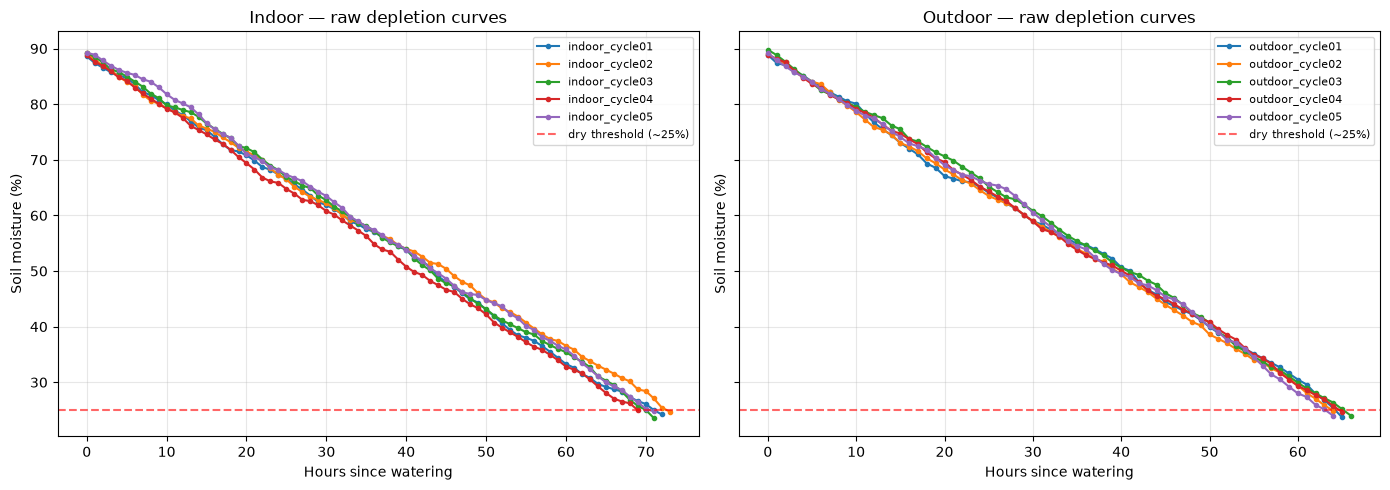

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, condition in zip(axes, ["indoor", "outdoor"]):
    for cycle_id, df in raw_cycles.items():
        if condition in cycle_id:
            hours = np.arange(len(df))
            ax.plot(hours, df["soil_moisture_pct"], marker="o", markersize=3, label=cycle_id)
    ax.axhline(25, color="red", linestyle="--", alpha=0.6, label="dry threshold (~25%)")
    ax.set_title(f"{condition.capitalize()} — raw depletion curves")
    ax.set_xlabel("Hours since watering")
    ax.set_ylabel("Soil moisture (%)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_raw_depletion_curves.png", dpi=120)
plt.show()

## Cycle count per condition

In [9]:
condition_counts = all_raw.groupby("condition")["cycle_id"].nunique()
print("Cycles collected so far:")
print(condition_counts)
print(f"\nTotal cycles: {condition_counts.sum()}")
print(f"Total hourly rows: {len(all_raw)}")

Cycles collected so far:
condition
indoor     5
outdoor    5
Name: cycle_id, dtype: int64

Total cycles: 10
Total hourly rows: 690


**Next step:** `02_data_cleaning_and_cycle_validation.ipynb` — build the cycle manifest and flag/exclude any contaminated cycles.